## Set up and extract data

In [8]:
import pandas as pd 
from IPython.display import display, Markdown, HTML
import matplotlib.pyplot as plt
from scipy import stats
import bs4
import xml.etree.ElementTree as ET
import bs4
import numpy as np
import math

# Format date
def format_date(date_in, format="%d %B %Y"):
    return date_in.strftime(format)

# Format a timedelta to years and days
def format_timedelta(td):
    years = td.days // 365
    days = td.days % 365
    
    year_str = f"{years} year{'s' if years != 1 else ''}"
    day_str = f"{days} day{'s' if days != 1 else ''}"
    
    return f"{year_str}, {day_str}"

# extract xml files from 7z format. check if the files exist first. 

import py7zr
import os

extract_dir = 'data'

def extract_and_prefix(stackname):
    archive = os.path.join(extract_dir,
                           f"{stackname}.stackexchange.com.7z")
    prefix  = stackname + '_'
    # if we already have at least one xml with that prefix, skip
    existing = [f for f in os.listdir(extract_dir)
                if f.startswith(prefix) and f.endswith('.xml')]
    if existing:
        print(f"{stackname} files already present ({len(existing)}); skipping.")
        return

    print(f"Extracting {stackname}…")
    with py7zr.SevenZipFile(archive, mode='r') as z:
        z.extractall(extract_dir)

    # rename any new xml files that lack a prefix
    for filename in os.listdir(extract_dir):
        if not filename.endswith('.xml'):
            continue
        if filename.startswith(prefix):
            continue
        # don't re‑rename files that already belong to another stack
        if any(filename.startswith(other) for other in
               ('buddhism_', 'christianity_', 'islam_')):
            continue
        old_path = os.path.join(extract_dir, filename)
        new_path = os.path.join(extract_dir, prefix + filename)
        os.rename(old_path, new_path)

for stack in ('buddhism', 'christianity', 'islam'):
    extract_and_prefix(stack)


import xml.etree.ElementTree as ET
import bs4
import numpy as np
import math



buddhism files already present (8); skipping.
christianity files already present (8); skipping.
islam files already present (8); skipping.


In [9]:

# built the three stacks into a dictionary, the analysis will loop through the stacks. 
STACKS = ['islam'] # replace 'islam' to load other stacks
COLORS = {'buddhism': '#e07b00', 'christianity': '#1a6ea8', 'islam': '#2a9d5c'}
LABELS = {'buddhism': 'Buddhism', 'christianity': 'Christianity', 'islam': 'Islam'}

def parse_xml_posts(path):
    tree = ET.parse(path)
    root = tree.getroot()
    data = [row.attrib for row in root.findall('row')]
    df = pd.DataFrame(data)
    df['CreationDate'] = pd.to_datetime(df['CreationDate'])
    if 'LastActivityDate' in df.columns:
        df['LastActivityDate'] = pd.to_datetime(df['LastActivityDate'])
    if 'LastEditDate' in df.columns:
        df['LastEditDate'] = pd.to_datetime(df['LastEditDate'], errors='coerce')
    if 'ClosedDate' in df.columns:
        df['ClosedDate'] = pd.to_datetime(df['ClosedDate'], errors='coerce')
    if 'Score' in df.columns:
        df['Score'] = pd.to_numeric(df['Score'], errors='coerce').fillna(0).astype(int)
    if 'AnswerCount' in df.columns:
        df['AnswerCount'] = pd.to_numeric(df['AnswerCount'], errors='coerce')
    if 'CommentCount' in df.columns:
        df['CommentCount'] = pd.to_numeric(df['CommentCount'], errors='coerce').fillna(0).astype(int)
    if 'ViewCount' in df.columns:
        df['ViewCount'] = pd.to_numeric(df['ViewCount'], errors='coerce')
    def extract_text(html):
        try:
            return bs4.BeautifulSoup(html, 'html.parser').get_text(separator=' ')
        except:
            return ''
    def extract_urls(html):
        try:
            soup = bs4.BeautifulSoup(html, 'html.parser')
            return [a['href'] for a in soup.find_all('a', href=True)]
        except:
            return []
    if 'Body' in df.columns:
        df['BodyText'] = df['Body'].apply(extract_text)
        df['BodyURLs'] = df['Body'].apply(extract_urls)
    else:
        df['BodyText'] = ''
        df['BodyURLs'] = [[] for _ in range(len(df))]
    return df

def parse_xml_comments(path):
    tree = ET.parse(path)
    root = tree.getroot()
    data = [row.attrib for row in root.findall('row')]
    df = pd.DataFrame(data)
    df['CreationDate'] = pd.to_datetime(df['CreationDate'])
    return df

stacks = {}
for name in STACKS:
    print(f'Loading {name}...')
    s_df = parse_xml_posts(f'data/{name}_Posts.xml')
    question_df = s_df[s_df['PostTypeId'] == '1'].copy()
    answer_df   = s_df[s_df['PostTypeId'] == '2'].copy()
    stacks[name] = {'stack_df': s_df, 'question_df': question_df, 'answer_df': answer_df}
    print(f'  {len(s_df)} total posts ({len(question_df)} questions, {len(answer_df)} answers)')
print('All stacks loaded.')


Loading islam...
  38592 total posts (15013 questions, 22764 answers)
All stacks loaded.


## Descriptive statistics

In [10]:
rows = []
for name in STACKS:
    sd = stacks[name]['stack_df']
    qd = stacks[name]['question_df']
    ad = stacks[name]['answer_df']
    first_q = sd['CreationDate'].min()
    last_act = sd['LastActivityDate'].max() if 'LastActivityDate' in sd.columns else sd['CreationDate'].max()
    time_range = last_act - first_q
    most_ans_row = qd.loc[qd['AnswerCount'].idxmax()]
    highest_score_row = sd.loc[sd['Score'].idxmax()]
    rows.append({
        'Stack': LABELS[name],
        'First post': format_date(first_q),
        'Last activity': format_date(last_act),
        'Span': format_timedelta(time_range),
        'Total questions': len(qd),
        'Total answers': len(ad),
        'Most answers': int(most_ans_row['AnswerCount']),
        'Most-answered title': most_ans_row.get('Title', 'N/A'),
        'Highest score': int(highest_score_row['Score']),
        'Highest-score title': highest_score_row.get('Title', 'N/A'),
    })
    md = (f"### {LABELS[name]}\n"
          f"- **First post:** {format_date(first_q)} | **Last activity:** {format_date(last_act)} | **Span:** {format_timedelta(time_range)}\n"
          f"- **Total questions:** {len(qd):,} | **Total answers:** {len(ad):,}\n"
          f"- **Most-answered question** ({int(most_ans_row['AnswerCount'])} answers): *{most_ans_row.get('Title','N/A')}*\n"
          f"- **Highest-scored post** (score {int(highest_score_row['Score'])}): *{highest_score_row.get('Title','N/A')}*\n")
    display(Markdown(md))

header = '| Metric | ' + ' | '.join(LABELS[n] for n in STACKS) + ' |'
sep    = '|-' + '|-' * len(STACKS) + '|'
metrics = [
    ('First post',        lambda r: r['First post']),
    ('Last activity',     lambda r: r['Last activity']),
    ('Span',              lambda r: r['Span']),
    ('Total questions',   lambda r: f"{r['Total questions']:,}"),
    ('Total answers',     lambda r: f"{r['Total answers']:,}"),
    ('Most answers',      lambda r: str(r['Most answers'])),
    ('Highest score',     lambda r: str(r['Highest score'])),
]
table = header + '\n' + sep
for label, fn in metrics:
    row_vals = ' | '.join(fn(r) for r in rows)
    table += f'\n| {label} | {row_vals} |'
display(Markdown('\n**Table R1.** Overview statistics for each religion Stack Exchange.\n\n' + table))


### Islam
- **First post:** 19 June 2012 | **Last activity:** 06 April 2024 | **Span:** 11 years, 293 days
- **Total questions:** 15,013 | **Total answers:** 22,764
- **Most-answered question** (22 answers): *Can Allah create a rock that He can't lift?*
- **Highest-scored post** (score 89): *Is evolution compatible with Islam?*



**Table R1.** Overview statistics for each religion Stack Exchange.

| Metric | Islam |
|-|-|
| First post | 19 June 2012 |
| Last activity | 06 April 2024 |
| Span | 11 years, 293 days |
| Total questions | 15,013 |
| Total answers | 22,764 |
| Most answers | 22 |
| Highest score | 89 |

## User Participation in Posts


In [11]:
def post_user_stats(stack_df_in, label):
    num_pst = len(stack_df_in)
    num_pst_miss = stack_df_in['OwnerUserId'].isna().sum()
    pct_pst_miss = num_pst_miss / num_pst
    user_freq = stack_df_in['OwnerUserId'].value_counts()
    user_count = len(user_freq)
    user_sum = int(user_freq.sum())
    user_mean = user_freq.mean()
    top_10_count = math.ceil(user_count * 0.1)
    top_10_freq  = user_freq.head(top_10_count)
    top_10_sum   = int(top_10_freq.sum())
    top_10_mean  = top_10_freq.mean()
    pct_top_10   = top_10_sum / num_pst
    top_1_count  = math.ceil(user_count * 0.01)
    top_1_freq   = user_freq.head(top_1_count)
    top_1_sum    = int(top_1_freq.sum())
    top_1_mean   = top_1_freq.mean()
    pct_top_1    = top_1_sum / num_pst
    return dict(label=label, num_pst_miss=num_pst_miss, pct_pst_miss=pct_pst_miss,
                user_count=user_count, user_sum=user_sum, user_mean=user_mean,
                top_10_count=top_10_count, top_10_sum=top_10_sum, top_10_mean=top_10_mean, pct_top_10=pct_top_10,
                top_1_count=top_1_count, top_1_sum=top_1_sum, top_1_mean=top_1_mean, pct_top_1=pct_top_1)

post_stats = {n: post_user_stats(stacks[n]['stack_df'], LABELS[n]) for n in STACKS}

for n in STACKS:
    s = post_stats[n]
    md_out = f"#### {s['label']}\n"
    md_out += (f"Posts were made by at least {s['user_count']} contributors "
               f"({s['pct_pst_miss']:.1%} of posts had deleted usernames). "
               f"On average, each valid user made {s['user_mean']:.2f} posts. "
               f"The top 10% made {s['pct_top_10']:.1%} of all posts; "
               f"the top 1% made {s['pct_top_1']:.1%} ({s['top_1_mean']:.1f} posts/user).\n\n")
    md_out += (f"**Table R2: {s['label']}**\n"
               "|| $n_{posts}$ | $\\bar{x}_{posts}$ |\n|-|-|-|\n"
               f"|Deleted usernames (n={s['num_pst_miss']})|{s['num_pst_miss']}|n/a|\n"
               f"|All valid users (n={s['user_count']})|{s['user_sum']}|{s['user_mean']:.2f}|\n"
               f"|Top 10% (n={s['top_10_count']})|{s['top_10_sum']}|{s['top_10_mean']:.2f}|\n"
               f"|Top 1% (n={s['top_1_count']})|{s['top_1_sum']}|{s['top_1_mean']:.2f}|\n")
    display(Markdown(md_out))

hdr = '| Metric | ' + ' | '.join(LABELS[n] for n in STACKS) + ' |'
sep = '|-' + '|-' * len(STACKS) + '|'
rows_cmp = [
    ('Valid users',        lambda s: str(s['user_count'])),
    ('Deleted-name posts', lambda s: str(s['num_pst_miss'])),
    ('Mean posts/user',    lambda s: f"{s['user_mean']:.2f}"),
    ('Top 10% share',      lambda s: f"{s['pct_top_10']:.1%}"),
    ('Top 1% share',       lambda s: f"{s['pct_top_1']:.1%}"),
    ('Top 1% mean posts',  lambda s: f"{s['top_1_mean']:.1f}"),
]
table = hdr + '\n' + sep
for label, fn in rows_cmp:
    vals = ' | '.join(fn(post_stats[n]) for n in STACKS)
    table += f'\n| {label} | {vals} |'
display(Markdown('\n**Table R2 (comparison).** Post user stats across all three stacks.\n\n' + table))


#### Islam
Posts were made by at least 10480 contributors (5.4% of posts had deleted usernames). On average, each valid user made 3.48 posts. The top 10% made 64.2% of all posts; the top 1% made 39.1% (143.7 posts/user).

**Table R2: Islam**
|| $n_{posts}$ | $\bar{x}_{posts}$ |
|-|-|-|
|Deleted usernames (n=2094)|2094|n/a|
|All valid users (n=10480)|36498|3.48|
|Top 10% (n=1048)|24777|23.64|
|Top 1% (n=105)|15088|143.70|



**Table R2 (comparison).** Post user stats across all three stacks.

| Metric | Islam |
|-|-|
| Valid users | 10480 |
| Deleted-name posts | 2094 |
| Mean posts/user | 3.48 |
| Top 10% share | 64.2% |
| Top 1% share | 39.1% |
| Top 1% mean posts | 143.7 |

## User participation in answers

In [12]:
def answer_user_stats(answer_df_in, label):
    num_ans = len(answer_df_in)
    num_ans_miss = answer_df_in['OwnerUserId'].isna().sum()
    pct_ans_miss = num_ans_miss / num_ans
    user_freq = answer_df_in['OwnerUserId'].value_counts()
    user_count = len(user_freq)
    user_sum = int(user_freq.sum())
    user_mean = user_freq.mean()
    top_10_count = math.ceil(user_count * 0.1)
    top_10_freq  = user_freq.head(top_10_count)
    top_10_sum   = int(top_10_freq.sum())
    top_10_mean  = top_10_freq.mean()
    pct_top_10   = top_10_sum / num_ans
    top_1_count  = math.ceil(user_count * 0.01)
    top_1_freq   = user_freq.head(top_1_count)
    top_1_sum    = int(top_1_freq.sum())
    top_1_mean   = top_1_freq.mean()
    pct_top_1    = top_1_sum / num_ans
    return dict(label=label, num_ans_miss=num_ans_miss, pct_ans_miss=pct_ans_miss,
                user_count=user_count, user_sum=user_sum, user_mean=user_mean,
                top_10_count=top_10_count, top_10_sum=top_10_sum, top_10_mean=top_10_mean, pct_top_10=pct_top_10,
                top_1_count=top_1_count, top_1_sum=top_1_sum, top_1_mean=top_1_mean, pct_top_1=pct_top_1)

ans_stats = {n: answer_user_stats(stacks[n]['answer_df'], LABELS[n]) for n in STACKS}

for n in STACKS:
    s = ans_stats[n]
    md_out = f"#### {s['label']}\n"
    md_out += (f"Answers were posted by at least {s['user_count']} contributors "
               f"({s['pct_ans_miss']:.1%} had deleted usernames). "
               f"Mean: {s['user_mean']:.2f} answers/user. "
               f"Top 10% made {s['pct_top_10']:.1%}; top 1% made {s['pct_top_1']:.1%} "
               f"({s['top_1_mean']:.1f} answers/user).\n\n")
    md_out += (f"**Table R3: {s['label']}**\n"
               "|| $n_{answers}$ | $\\bar{x}_{answers}$ |\n|-|-|-|\n"
               f"|Deleted usernames (n={s['num_ans_miss']})|{s['num_ans_miss']}|n/a|\n"
               f"|All valid users (n={s['user_count']})|{s['user_sum']}|{s['user_mean']:.2f}|\n"
               f"|Top 10% (n={s['top_10_count']})|{s['top_10_sum']}|{s['top_10_mean']:.2f}|\n"
               f"|Top 1% (n={s['top_1_count']})|{s['top_1_sum']}|{s['top_1_mean']:.2f}|\n")
    display(Markdown(md_out))

hdr = '| Metric | ' + ' | '.join(LABELS[n] for n in STACKS) + ' |'
sep = '|-' + '|-' * len(STACKS) + '|'
rows_cmp = [
    ('Valid users',          lambda s: str(s['user_count'])),
    ('Mean answers/user',    lambda s: f"{s['user_mean']:.2f}"),
    ('Top 10% share',        lambda s: f"{s['pct_top_10']:.1%}"),
    ('Top 1% share',         lambda s: f"{s['pct_top_1']:.1%}"),
    ('Top 1% mean answers',  lambda s: f"{s['top_1_mean']:.1f}"),
]
table = hdr + '\n' + sep
for label, fn in rows_cmp:
    vals = ' | '.join(fn(ans_stats[n]) for n in STACKS)
    table += f'\n| {label} | {vals} |'
display(Markdown('\n**Table R3 (comparison).** Answer user stats across all three stacks.\n\n' + table))


#### Islam
Answers were posted by at least 4887 contributors (4.5% had deleted usernames). Mean: 4.45 answers/user. Top 10% made 69.5%; top 1% made 42.1% (195.4 answers/user).

**Table R3: Islam**
|| $n_{answers}$ | $\bar{x}_{answers}$ |
|-|-|-|
|Deleted usernames (n=1030)|1030|n/a|
|All valid users (n=4887)|21734|4.45|
|Top 10% (n=489)|15815|32.34|
|Top 1% (n=49)|9575|195.41|



**Table R3 (comparison).** Answer user stats across all three stacks.

| Metric | Islam |
|-|-|
| Valid users | 4887 |
| Mean answers/user | 4.45 |
| Top 10% share | 69.5% |
| Top 1% share | 42.1% |
| Top 1% mean answers | 195.4 |

## User overlap between questions and answers

In [13]:
def user_overlap_stats(question_df_in, answer_df_in, label):
    question_users = set(question_df_in['OwnerUserId'].dropna())
    answer_users   = set(answer_df_in['OwnerUserId'].dropna())
    only_q  = question_users - answer_users
    only_a  = answer_users - question_users
    both    = question_users & answer_users
    all_u   = question_users | answer_users
    oq_posts = question_df_in[question_df_in['OwnerUserId'].isin(only_q)].groupby('OwnerUserId').size()
    oa_posts = answer_df_in[answer_df_in['OwnerUserId'].isin(only_a)].groupby('OwnerUserId').size()
    bq_posts = question_df_in[question_df_in['OwnerUserId'].isin(both)].groupby('OwnerUserId').size()
    ba_posts = answer_df_in[answer_df_in['OwnerUserId'].isin(both)].groupby('OwnerUserId').size()
    return dict(label=label, all_n=len(all_u),
                only_q_n=len(only_q), only_q_sum=oq_posts.sum(), only_q_mean=oq_posts.mean(), only_q_med=oq_posts.median(),
                only_a_n=len(only_a), only_a_sum=oa_posts.sum(), only_a_mean=oa_posts.mean(), only_a_med=oa_posts.median(),
                both_n=len(both),
                both_q_sum=bq_posts.sum(), both_q_mean=bq_posts.mean(), both_q_med=bq_posts.median(),
                both_a_sum=ba_posts.sum(), both_a_mean=ba_posts.mean(), both_a_med=ba_posts.median())

overlap_stats = {n: user_overlap_stats(stacks[n]['question_df'], stacks[n]['answer_df'], LABELS[n]) for n in STACKS}

for n in STACKS:
    s = overlap_stats[n]
    md_out = f"#### {s['label']}\n"
    md_out += (f"Of the {s['all_n']} total users, {s['only_q_n']} only asked questions, "
               f"{s['only_a_n']} only answered, and {s['both_n']} did both.\n\n")
    md_out += (f"**Table R4: {s['label']}**\n"
               "|| $n_{questions}$ | $\\bar{{x}}$ | p50 | $n_{{answers}}$ | $\\bar{{x}}$ | p50 |\n"
               "|-|-|-|-|-|-|-|\n"
               f"|Only questions (n={s['only_q_n']})|{s['only_q_sum']}|{s['only_q_mean']:.2f}|{s['only_q_med']}|n/a|n/a|n/a|\n"
               f"|Only answers (n={s['only_a_n']})|n/a|n/a|n/a|{s['only_a_sum']}|{s['only_a_mean']:.2f}|{s['only_a_med']}|\n"
               f"|Both (n={s['both_n']})|{s['both_q_sum']}|{s['both_q_mean']:.2f}|{s['both_q_med']}|{s['both_a_sum']}|{s['both_a_mean']:.2f}|{s['both_a_med']}|\n")
    display(Markdown(md_out))

hdr = '| Metric | ' + ' | '.join(LABELS[n] for n in STACKS) + ' |'
sep = '|-' + '|-' * len(STACKS) + '|'
rows_cmp = [
    ('Total unique users',   lambda s: str(s['all_n'])),
    ('Only asked',           lambda s: str(s['only_q_n'])),
    ('Only answered',        lambda s: str(s['only_a_n'])),
    ('Asked & answered',     lambda s: str(s['both_n'])),
]
table = hdr + '\n' + sep
for label, fn in rows_cmp:
    vals = ' | '.join(fn(overlap_stats[n]) for n in STACKS)
    table += f'\n| {label} | {vals} |'
display(Markdown('\n**Table R4 (comparison).** User overlap (questions vs answers) across all three stacks.\n\n' + table))


#### Islam
Of the 10474 total users, 5587 only asked questions, 4016 only answered, and 871 did both.

**Table R4: Islam**
|| $n_{questions}$ | $\bar{{x}}$ | p50 | $n_{{answers}}$ | $\bar{{x}}$ | p50 |
|-|-|-|-|-|-|-|
|Only questions (n=5587)|8050|1.44|1.0|n/a|n/a|n/a|
|Only answers (n=4016)|n/a|n/a|n/a|7736|1.93|1.0|
|Both (n=871)|5933|6.81|2.0|13998|16.07|2.0|



**Table R4 (comparison).** User overlap (questions vs answers) across all three stacks.

| Metric | Islam |
|-|-|
| Total unique users | 10474 |
| Only asked | 5587 |
| Only answered | 4016 |
| Asked & answered | 871 |

## Activity over time in 3 month windows

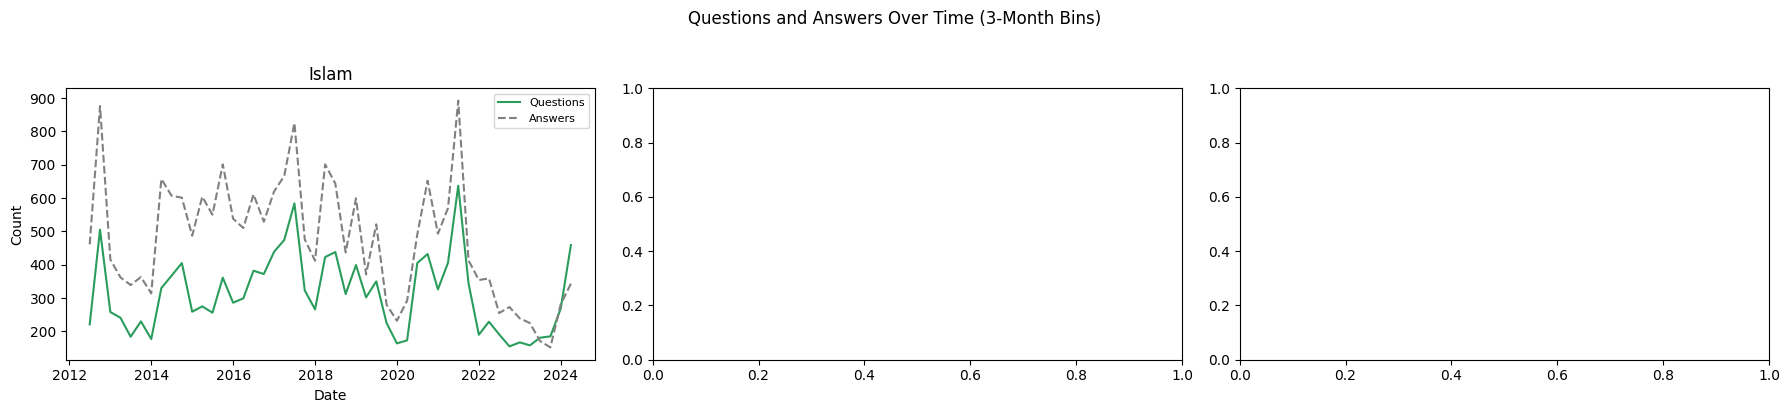

**Figure R1.** Questions and answers over time for each religion stack.

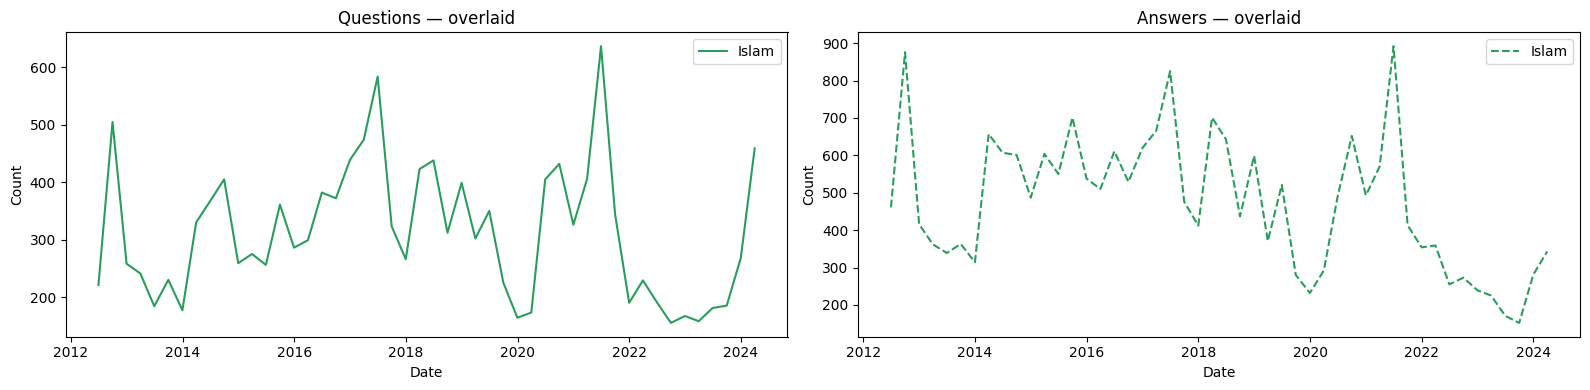

**Figure R2.** Overlaid question and answer volumes across all three stacks.

**Pearson correlation (questions vs answers, 3-month bins):**

| Stack | r | p |
|-|-|-|
| Islam | 0.864 | 2.84e-15 |


In [14]:
import seaborn as sns

questions_3m_all = {}
answers_3m_all   = {}
for n in STACKS:
    q = stacks[n]['question_df']
    a = stacks[n]['answer_df']
    questions_3m_all[n] = q.resample('3ME', on='CreationDate').count()['Id']
    answers_3m_all[n]   = a.resample('3ME', on='CreationDate').count()['Id']

# Side-by-side: one subplot per stack
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, n in zip(axes, STACKS):
    ax.plot(questions_3m_all[n].index, questions_3m_all[n].values, label='Questions', color=COLORS[n])
    ax.plot(answers_3m_all[n].index,   answers_3m_all[n].values,   label='Answers',   color='grey', linestyle='--')
    ax.set_title(LABELS[n]); ax.set_xlabel('Date'); ax.set_ylabel('Count'); ax.legend(fontsize=8)
plt.suptitle('Questions and Answers Over Time (3-Month Bins)', y=1.02)
plt.tight_layout(); plt.show()
display(Markdown('**Figure R1.** Questions and answers over time for each religion stack.'))

# Overlaid
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for n in STACKS:
    axes[0].plot(questions_3m_all[n].index, questions_3m_all[n].values, label=LABELS[n], color=COLORS[n])
    axes[1].plot(answers_3m_all[n].index,   answers_3m_all[n].values,   label=LABELS[n], color=COLORS[n], linestyle='--')
axes[0].set_title('Questions — overlaid'); axes[0].set_xlabel('Date'); axes[0].set_ylabel('Count'); axes[0].legend()
axes[1].set_title('Answers — overlaid');   axes[1].set_xlabel('Date'); axes[1].set_ylabel('Count'); axes[1].legend()
plt.tight_layout(); plt.show()
display(Markdown('**Figure R2.** Overlaid question and answer volumes across all three stacks.'))

# Pearson correlations
md_corr = '**Pearson correlation (questions vs answers, 3-month bins):**\n\n| Stack | r | p |\n|-|-|-|\n'
for n in STACKS:
    q3, a3 = questions_3m_all[n].align(answers_3m_all[n], join='outer', fill_value=0)
    r, pv = stats.pearsonr(q3, a3)
    md_corr += f'| {LABELS[n]} | {r:.3f} | {pv:.3g} |\n'
display(Markdown(md_corr))


## Post score over time

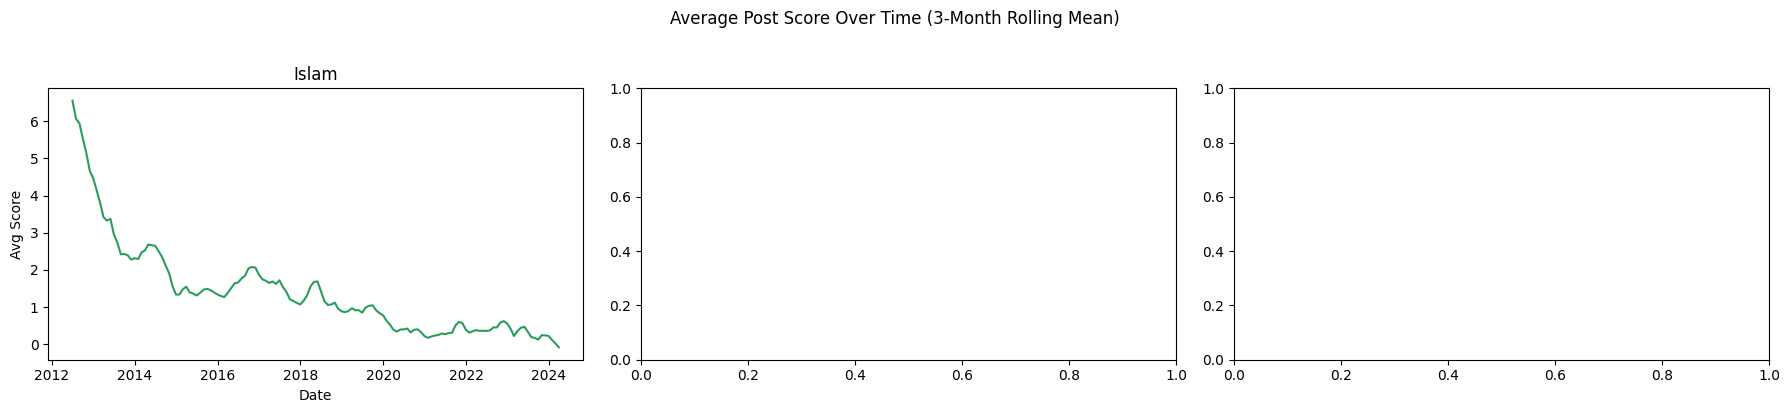

**Figure R3.** Average post score over time for each religion stack.

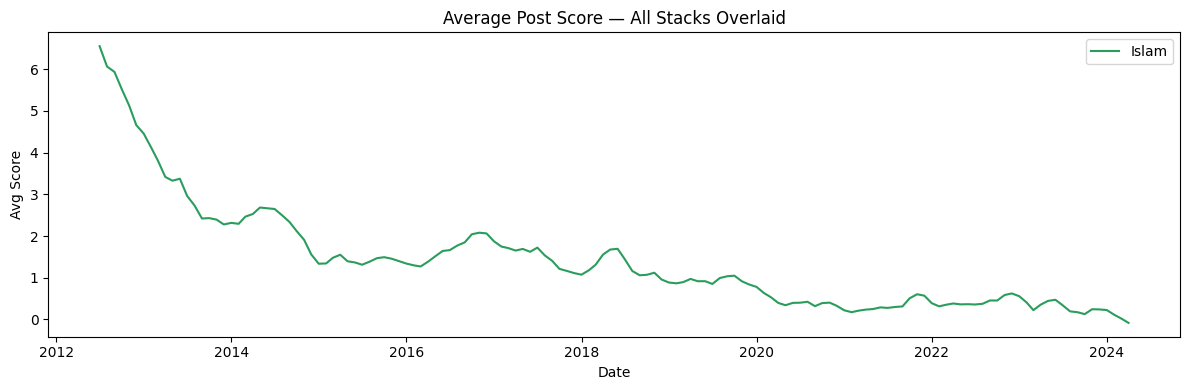

**Figure R4.** Overlaid average post score comparison.

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, n in zip(axes, STACKS):
    p = stacks[n]['stack_df']
    monthly = p.resample('ME', on='CreationDate')['Score'].mean()
    rolling = monthly.rolling(window=3, min_periods=1).mean()
    ax.plot(rolling.index, rolling.values, color=COLORS[n])
    ax.set_title(LABELS[n]); ax.set_xlabel('Date'); ax.set_ylabel('Avg Score')
plt.suptitle('Average Post Score Over Time (3-Month Rolling Mean)', y=1.02)
plt.tight_layout(); plt.show()
display(Markdown('**Figure R3.** Average post score over time for each religion stack.'))

plt.figure(figsize=(12, 4))
for n in STACKS:
    p = stacks[n]['stack_df']
    monthly = p.resample('ME', on='CreationDate')['Score'].mean()
    rolling = monthly.rolling(window=3, min_periods=1).mean()
    plt.plot(rolling.index, rolling.values, label=LABELS[n], color=COLORS[n])
plt.title('Average Post Score — All Stacks Overlaid')
plt.xlabel('Date'); plt.ylabel('Avg Score'); plt.legend()
plt.tight_layout(); plt.show()
display(Markdown('**Figure R4.** Overlaid average post score comparison.'))
